# Comparación de modelos predictivos para el pronóstico del precio de cierre de META

In [ ]:
#!pip install yfinance
#!pip install skforecast --quiet

In [1]:
import sys
print(sys.version)

3.11.15 (main, Mar 11 2026, 17:14:47) [Clang 20.1.8 ]


## 1. Librerias 

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

from skforecast.recursive import ForecasterRecursive


## 2. descarga datos 

In [3]:
ticker = "META"

data = yf.download(
    ticker,
    start="2016-05-01",
    end="2018-01-28",
    progress=False
)

data.head()

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2016-05-02,117.646774,117.805532,115.662347,116.912538,28095200
2016-05-03,116.515640,117.239959,116.108829,116.604936,24117500
2016-05-04,117.140732,117.378869,115.662336,115.702025,23448400
2016-05-05,116.892685,118.053581,116.337048,117.120897,22056700
2016-05-06,118.559593,118.708427,116.198128,116.247741,26395600


### para este trabajo usaremos el precio de cierre 

In [4]:
serie = data[["Close"]].copy()
serie = serie.dropna()

serie.head()

Price,Close
Ticker,META
Date,
2016-05-02,117.646774
2016-05-03,116.515640
2016-05-04,117.140732
2016-05-05,116.892685
2016-05-06,118.559593


In [5]:
serie.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 439 entries, 2016-05-02 to 2018-01-26
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, META)  439 non-null    float64
dtypes: float64(1)
memory usage: 6.9 KB


## 3. Limpiamos serie

In [6]:
# serie formato simple
serie = data[("Close", "META")].copy()

# Convertimos a DF
serie = serie.to_frame(name="Close")
serie = serie.dropna()


serie.head()

,Close
Date,
2016-05-02,117.646774
2016-05-03,116.515640
2016-05-04,117.140732
2016-05-05,116.892685
2016-05-06,118.559593


In [7]:
serie.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 439 entries, 2016-05-02 to 2018-01-26
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   439 non-null    float64
dtypes: float64(1)
memory usage: 6.9 KB


## 4. Visualización serie 

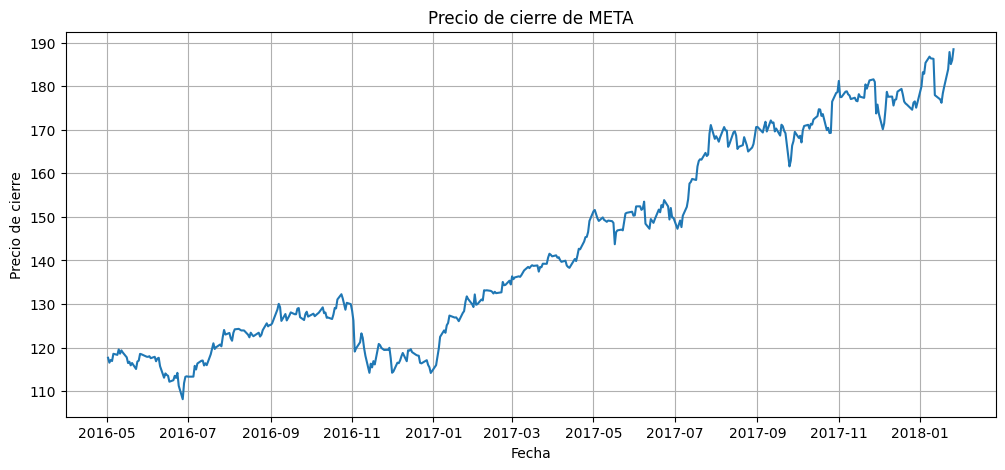

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(serie.index, serie["Close"])
plt.title("Precio de cierre de META")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.grid(True)
plt.show()

## 5. Procesamiento y separar serie en prueba y entramiento

In [9]:
split_percent = 0.95
split = int(split_percent * len(serie))

data_train = serie.iloc[:split].copy()
data_test = serie.iloc[split:].copy()

print("Total de datos:", len(serie))
print("Datos de entrenamiento:", len(data_train))
print("Datos de prueba:", len(data_test))

print("\nRango entrenamiento:")
print(data_train.index.min(), "hasta", data_train.index.max())

print("\nRango prueba:")
print(data_test.index.min(), "hasta", data_test.index.max())

Total de datos: 439
Datos de entrenamiento: 417
Datos de prueba: 22

Rango entrenamiento:
2016-05-02 00:00:00 hasta 2017-12-22 00:00:00

Rango prueba:
2017-12-26 00:00:00 hasta 2018-01-26 00:00:00


### Grafica de la partición

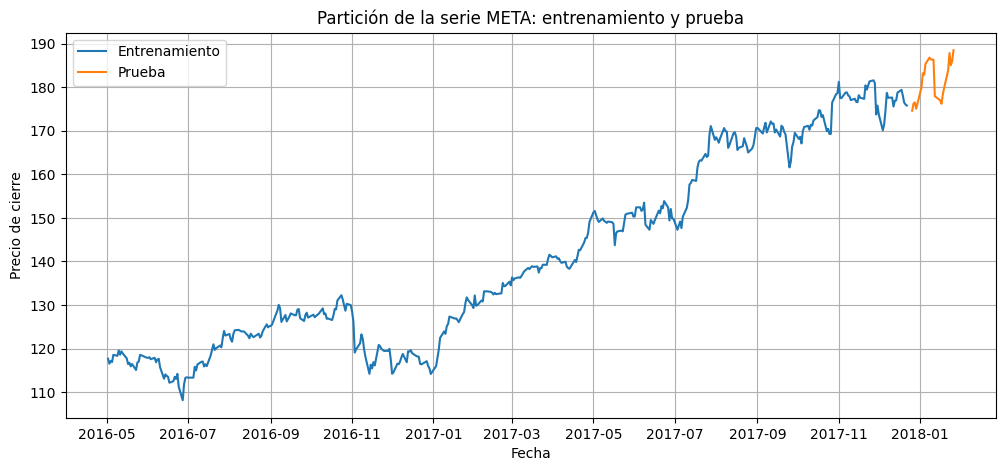

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(data_train.index, data_train["Close"], label="Entrenamiento")
plt.plot(data_test.index, data_test["Close"], label="Prueba")

plt.title("Partición de la serie META: entrenamiento y prueba")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.grid(True)
plt.show()

## 6. Modelos 

#### funciond de metrcias 

In [17]:
def calcular_metricas(y_real, y_pred):
    y_real = np.array(y_real).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)
    
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    
    return mae, rmse, mape

### Modelo Random Forest

In [11]:
data_rf = serie.rename(columns={"Close": "y"}).copy()

data_rf.head()

,y
Date,
2016-05-02,117.646774
2016-05-03,116.515640
2016-05-04,117.140732
2016-05-05,116.892685
2016-05-06,118.559593


### particion de datos

In [12]:
split_percent = 0.05
split = int(split_percent * len(data_rf))

data_train_rf = data_rf[:-split].copy()
data_test_rf = data_rf[-split:].copy()

date_train_rf = data_train_rf.index
date_test_rf = data_test_rf.index

print("Longitud entrenamiento:", len(data_train_rf))
print("Longitud prueba:", len(data_test_rf))

Longitud entrenamiento: 418
Longitud prueba: 21


### Visualización entrenamiento

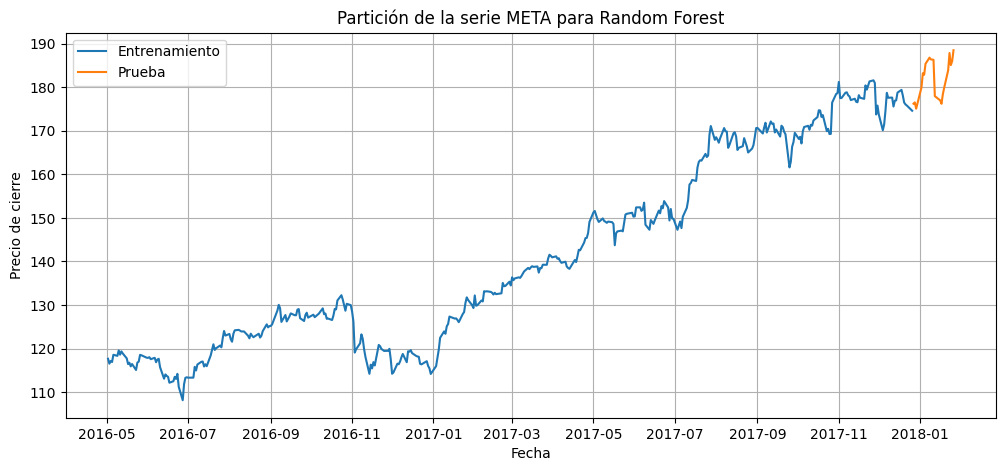

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(date_train_rf, data_train_rf["y"], label="Entrenamiento")
plt.plot(date_test_rf, data_test_rf["y"], label="Prueba")

plt.title("Partición de la serie META para Random Forest")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.grid(True)
plt.show()

#### Preparación del índice para skforecast

In [14]:
y_train_rf = data_train_rf["y"].reset_index(drop=True)
y_test_rf = data_test_rf["y"].reset_index(drop=True)

fechas_test_rf = data_test_rf.index

#### Modelo RF base con 10 rezagos

In [15]:
regressor_rf_base = RandomForestRegressor(
    random_state=123
)

forecaster_rf_base = ForecasterRecursive(
    estimator=regressor_rf_base,
    lags=10
)

forecaster_rf_base.fit(y=y_train_rf)

pred_rf_base = forecaster_rf_base.predict(steps=len(y_test_rf))

resultados_rf_base = pd.DataFrame({
    "Real": data_test_rf["y"].values,
    "Pred_RF_Base": pred_rf_base.values
}, index=fechas_test_rf)

resultados_rf_base.head()

,Real,Pred_RF_Base
Date,,
2017-12-27,176.236969,175.557321
2017-12-28,176.534653,176.568288
2017-12-29,175.086029,177.792279
2018-01-02,180.007370,178.032990
2018-01-03,183.232086,178.420549


#### Métricas RF base

In [18]:
mae_rf_base, rmse_rf_base, mape_rf_base = calcular_metricas(
    resultados_rf_base["Real"],
    resultados_rf_base["Pred_RF_Base"]
)

metricas_rf_base = pd.DataFrame({
    "Modelo": ["Random Forest base"],
    "MAE": [mae_rf_base],
    "RMSE": [rmse_rf_base],
    "MAPE (%)": [mape_rf_base]
})

metricas_rf_base

,Modelo,MAE,RMSE,MAPE (%)
0,Random Forest base,4.930352,6.089056,2.662185


#### Grid search manual

In [19]:
resultados_grid_rf_2 = []

lags_grid = [8, 10, 12, 15]
max_depth_grid = [4, 5, 6, 7]
n_estimators_grid = [200, 300, 400, 500]
min_samples_leaf_grid = [1, 2, 3]
min_samples_split_grid = [2, 5, 10]

for lags in lags_grid:
    for max_depth in max_depth_grid:
        for n_estimators in n_estimators_grid:
            for min_samples_leaf in min_samples_leaf_grid:
                for min_samples_split in min_samples_split_grid:
                    
                    regressor = RandomForestRegressor(
                        n_estimators=n_estimators,
                        max_depth=max_depth,
                        min_samples_leaf=min_samples_leaf,
                        min_samples_split=min_samples_split,
                        random_state=123
                    )
                    
                    forecaster = ForecasterRecursive(
                        estimator=regressor,
                        lags=lags
                    )
                    
                    forecaster.fit(y=y_train_rf)
                    pred = forecaster.predict(steps=len(y_test_rf))
                    
                    mae, rmse, mape = calcular_metricas(y_test_rf, pred)
                    
                    resultados_grid_rf_2.append({
                        "lags": lags,
                        "max_depth": max_depth,
                        "n_estimators": n_estimators,
                        "min_samples_leaf": min_samples_leaf,
                        "min_samples_split": min_samples_split,
                        "MAE": mae,
                        "RMSE": rmse,
                        "MAPE (%)": mape
                    })

grid_rf_2 = pd.DataFrame(resultados_grid_rf_2)

grid_rf_2.sort_values("RMSE").head(10)

,lags,max_depth,n_estimators,min_samples_leaf,min_samples_split,MAE,RMSE,MAPE (%)
402,12,7,200,3,2,4.683359,5.754850,2.529356
403,12,7,200,3,5,4.683359,5.754850,2.529356
259,10,7,200,3,5,4.705717,5.758482,2.541747
258,10,7,200,3,2,4.705717,5.758482,2.541747
256,10,7,200,2,5,4.818569,5.929304,2.602334
255,10,7,200,2,2,4.835957,5.941224,2.611898
366,12,6,200,3,2,4.913751,6.057559,2.653197
367,12,6,200,3,5,4.913751,6.057559,2.653197
152,10,4,200,3,10,4.919117,6.064529,2.656326
151,10,4,200,3,5,4.919117,6.064529,2.656326


#### Entrenamiento RF refinado

In [20]:
regressor_rf_final = RandomForestRegressor(
    n_estimators=400,
    max_depth=7,
    min_samples_leaf=3,
    min_samples_split=5,
    random_state=123
)

forecaster_rf_final = ForecasterRecursive(
    estimator=regressor_rf_final,
    lags=15
)

forecaster_rf_final.fit(y=y_train_rf)

pred_rf_final = forecaster_rf_final.predict(steps=len(y_test_rf))

resultados_rf_final = pd.DataFrame({
    "Real": data_test_rf["y"].values,
    "Pred_RF": pred_rf_final.values
}, index=fechas_test_rf)

resultados_rf_final.head()

,Real,Pred_RF
Date,,
2017-12-27,176.236969,175.680815
2017-12-28,176.534653,176.696696
2017-12-29,175.086029,178.026892
2018-01-02,180.007370,178.036434
2018-01-03,183.232086,178.191564


#### Métricas RF refinado

In [21]:
mae_rf_final, rmse_rf_final, mape_rf_final = calcular_metricas(
    resultados_rf_final["Real"],
    resultados_rf_final["Pred_RF"]
)

metricas_rf_final = pd.DataFrame({
    "Modelo": ["Random Forest refinado"],
    "MAE": [mae_rf_final],
    "RMSE": [rmse_rf_final],
    "MAPE (%)": [mape_rf_final]
})

metricas_rf_final

,Modelo,MAE,RMSE,MAPE (%)
0,Random Forest refinado,4.970664,6.117778,2.684428


#### Gráfico RF refinado

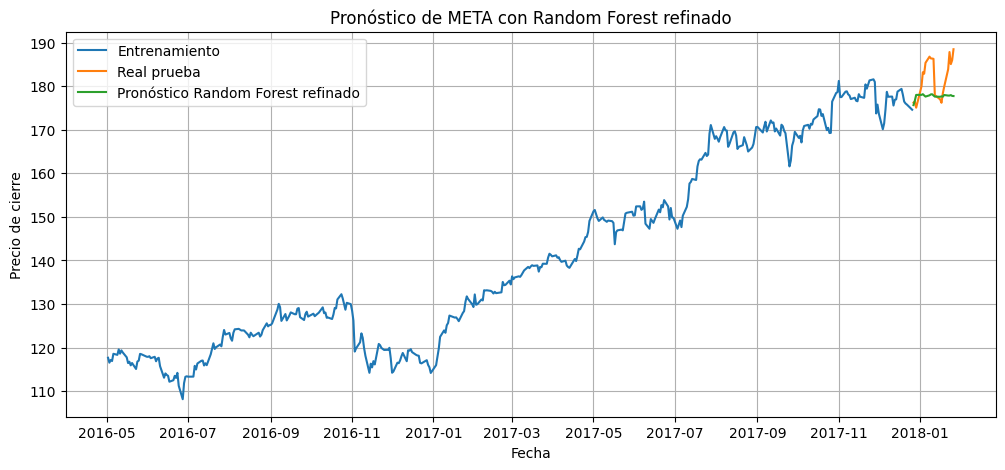

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(data_train_rf.index, data_train_rf["y"], label="Entrenamiento")
plt.plot(data_test_rf.index, data_test_rf["y"], label="Real prueba")
plt.plot(resultados_rf_final.index, resultados_rf_final["Pred_RF"], label="Pronóstico Random Forest refinado")

plt.title("Pronóstico de META con Random Forest refinado")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
importancia_rf = forecaster_rf_final.get_feature_importances()

importancia_rf

,feature,importance
0,lag_1,0.321828
2,lag_3,0.244447
1,lag_2,0.202896
4,lag_5,0.097244
3,lag_4,0.082788
5,lag_6,0.021949
6,lag_7,0.014398
8,lag_9,0.006947
7,lag_8,0.002863
9,lag_10,0.001409


La importancia de variables del modelo Random Forest muestra que los rezagos más cercanos al momento de predicción concentran la mayor capacidad explicativa. En particular, `lag_1`, `lag_3` y `lag_2` presentan las mayores importancias, lo cual indica que el modelo se apoya principalmente en la información reciente del precio de cierre para generar el pronóstico. Los rezagos más lejanos tienen una contribución menor, aunque se conservaron dentro del modelo porque hicieron parte de la configuración refinada que obtuvo el menor RMSE.

#### Pronostico futuro 10 dias 

In [24]:
y_full_rf = data_rf["y"].reset_index(drop=True)

forecaster_rf_futuro = ForecasterRecursive(
    estimator=regressor_rf_final,
    lags=15
)

forecaster_rf_futuro.fit(y=y_full_rf)

steps_futuro = 10
pred_rf_futuro = forecaster_rf_futuro.predict(steps=steps_futuro)

pred_rf_futuro

439    186.262538
440    185.943962
441    186.112858
442    185.303363
443    184.509383
444    184.200538
445    184.165486
446    185.144966
447    186.203959
448    186.192183
Name: pred, dtype: float64

#### Fechas futuras

In [26]:
fecha_inicio_futuro = data_rf.index.max() + pd.tseries.offsets.BDay(1)

fechas_futuras_rf = pd.bdate_range(
    start=fecha_inicio_futuro,
    periods=steps_futuro
)

pronostico_rf_futuro = pd.DataFrame({
    "Fecha": fechas_futuras_rf,
    "Pronostico_RF": pred_rf_futuro.values
})

pronostico_rf_futuro

,Fecha,Pronostico_RF
0,2018-01-29,186.262538
1,2018-01-30,185.943962
2,2018-01-31,186.112858
3,2018-02-01,185.303363
4,2018-02-02,184.509383
5,2018-02-05,184.200538
6,2018-02-06,184.165486
7,2018-02-07,185.144966
8,2018-02-08,186.203959
9,2018-02-09,186.192183


#### grafica pronostico futuro 

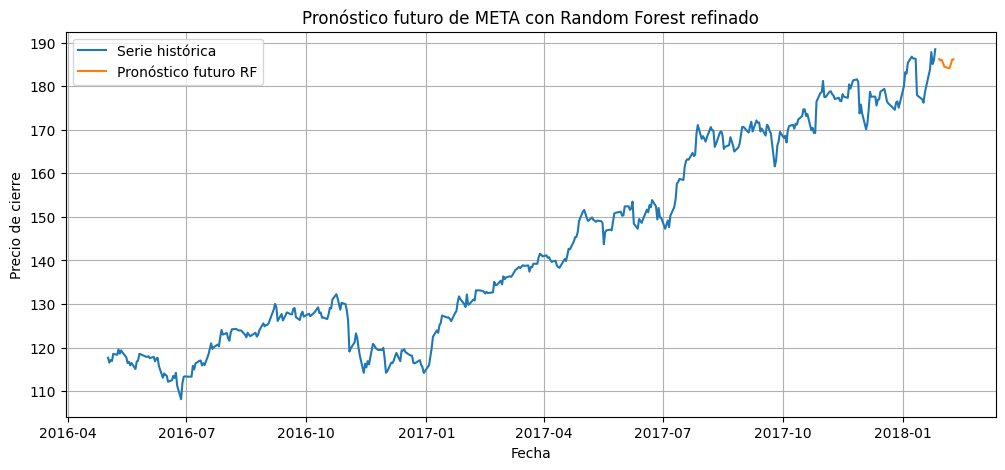

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(data_rf.index, data_rf["y"], label="Serie histórica")
plt.plot(fechas_futuras_rf, pred_rf_futuro.values, label="Pronóstico futuro RF")

plt.title("Pronóstico futuro de META con Random Forest refinado")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.grid(True)
plt.show()

El pronóstico futuro generado por el modelo Random Forest refinado muestra una trayectoria relativamente estable para los siguientes 10 días hábiles, con valores proyectados alrededor de 184 a 186 dólares. Este comportamiento es coherente con la naturaleza del modelo, ya que Random Forest tiende a generar predicciones dentro del rango observado en los datos recientes y no extrapola tendencias extremas con facilidad. Aun así, el modelo obtuvo el mejor desempeño dentro de la comparación preliminar, por lo que se conserva como candidato fuerte para la selección final.

### Modelo MARS 

In [ ]:
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

In [29]:
# Modelo tipo MARS - Preparación de datos

data_mars = serie.copy()
data_mars = data_mars.rename(columns={"Close": "Meta"})

print("Dimensión de data_mars:", data_mars.shape)
print(data_mars.head())
print(data_mars.tail())

Dimensión de data_mars: (439, 1)
                  Meta
Date                  
2016-05-02  117.646774
2016-05-03  116.515640
2016-05-04  117.140732
2016-05-05  116.892685
2016-05-06  118.559593
                  Meta
Date                  
2018-01-22  183.926636
2018-01-23  187.875671
2018-01-24  185.097458
2018-01-25  186.020187
2018-01-26  188.520569


#### Partición entrenamiento / prueba

In [30]:
split_percent = 0.95
split = int(split_percent * len(data_mars))

mars_train = data_mars.iloc[:split].copy()
mars_test = data_mars.iloc[split:].copy()

print("Total de datos:", len(data_mars))
print("Datos de entrenamiento:", len(mars_train))
print("Datos de prueba:", len(mars_test))

print("\nRango entrenamiento:")
print(mars_train.index.min(), "hasta", mars_train.index.max())

print("\nRango prueba:")
print(mars_test.index.min(), "hasta", mars_test.index.max())

Total de datos: 439
Datos de entrenamiento: 417
Datos de prueba: 22

Rango entrenamiento:
2016-05-02 00:00:00 hasta 2017-12-22 00:00:00

Rango prueba:
2017-12-26 00:00:00 hasta 2018-01-26 00:00:00


#### visualizar entrenamiento

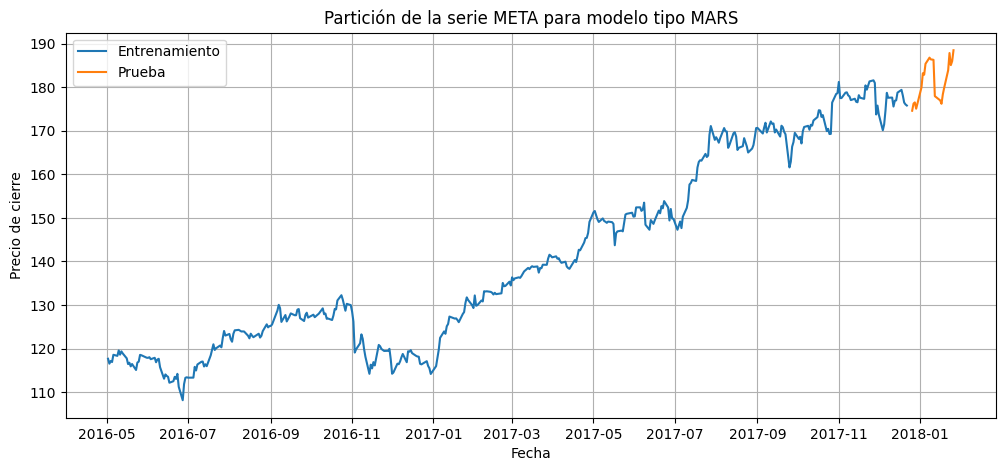

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(mars_train.index, mars_train["Meta"], label="Entrenamiento")
plt.plot(mars_test.index, mars_test["Meta"], label="Prueba")

plt.title("Partición de la serie META para modelo tipo MARS")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.grid(True)
plt.show()

La partición conserva el orden temporal de la serie, utilizando el primer 95% de observaciones para entrenamiento y el 5% final para prueba. Visualmente, el conjunto de prueba corresponde a un periodo de incremento en el precio de cierre de META, por lo que será útil para evaluar si el modelo logra capturar la tendencia reciente de la serie.

#### Generación de rezagos para MARS

In [32]:
def crear_rezagos_mars(data, variable="Meta", n_lags=10):
    df = data.copy()
    
    for lag in range(1, n_lags + 1):
        df[f"lag_{lag}"] = df[variable].shift(lag)
    
    df = df.dropna().copy()
    
    return df

n_lags_mars = 10

mars_train_lags = crear_rezagos_mars(
    mars_train,
    variable="Meta",
    n_lags=n_lags_mars
)

print("Dimensión mars_train_lags:", mars_train_lags.shape)
mars_train_lags.head()

Dimensión mars_train_lags: (407, 11)


,Meta,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10
Date,,,,,,,,,,,
2016-05-16,117.745995,118.877106,119.343452,118.589363,119.561737,118.311546,118.559593,116.892685,117.140732,116.515640,117.646774
2016-05-17,116.436272,117.745995,118.877106,119.343452,118.589363,119.561737,118.311546,118.559593,116.892685,117.140732,116.515640
2016-05-18,116.733940,116.436272,117.745995,118.877106,119.343452,118.589363,119.561737,118.311546,118.559593,116.892685,117.140732
2016-05-19,115.900482,116.733940,116.436272,117.745995,118.877106,119.343452,118.589363,119.561737,118.311546,118.559593,116.892685
2016-05-20,116.436272,115.900482,116.733940,116.436272,117.745995,118.877106,119.343452,118.589363,119.561737,118.311546,118.559593


La generación de rezagos transforma la serie de tiempo en un problema de aprendizaje supervisado. En este caso, el precio actual de cierre de META se modela a partir de sus 10 valores anteriores. Al construir estos rezagos se pierden las primeras 10 observaciones del conjunto de entrenamiento, lo cual es esperado porque no tienen suficiente historial previo para completar todas las variables explicativas.

#### agregar variable de tendencia

In [33]:
mars_train_lags["tendencia"] = np.arange(1, len(mars_train_lags) + 1)

print("Dimensión con tendencia:", mars_train_lags.shape)
mars_train_lags.head()

Dimensión con tendencia: (407, 12)


,Meta,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,tendencia
Date,,,,,,,,,,,,
2016-05-16,117.745995,118.877106,119.343452,118.589363,119.561737,118.311546,118.559593,116.892685,117.140732,116.515640,117.646774,1
2016-05-17,116.436272,117.745995,118.877106,119.343452,118.589363,119.561737,118.311546,118.559593,116.892685,117.140732,116.515640,2
2016-05-18,116.733940,116.436272,117.745995,118.877106,119.343452,118.589363,119.561737,118.311546,118.559593,116.892685,117.140732,3
2016-05-19,115.900482,116.733940,116.436272,117.745995,118.877106,119.343452,118.589363,119.561737,118.311546,118.559593,116.892685,4
2016-05-20,116.436272,115.900482,116.733940,116.436272,117.745995,118.877106,119.343452,118.589363,119.561737,118.311546,118.559593,5


#### separar X e y

In [34]:
y_train_mars = mars_train_lags["Meta"]

X_train_mars = mars_train_lags.drop(columns=["Meta"])

print("Dimensión X_train_mars:", X_train_mars.shape)
print("Dimensión y_train_mars:", y_train_mars.shape)

X_train_mars.head()

Dimensión X_train_mars: (407, 11)
Dimensión y_train_mars: (407,)


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,tendencia
Date,,,,,,,,,,,
2016-05-16,118.877106,119.343452,118.589363,119.561737,118.311546,118.559593,116.892685,117.140732,116.515640,117.646774,1
2016-05-17,117.745995,118.877106,119.343452,118.589363,119.561737,118.311546,118.559593,116.892685,117.140732,116.515640,2
2016-05-18,116.436272,117.745995,118.877106,119.343452,118.589363,119.561737,118.311546,118.559593,116.892685,117.140732,3
2016-05-19,116.733940,116.436272,117.745995,118.877106,119.343452,118.589363,119.561737,118.311546,118.559593,116.892685,4
2016-05-20,115.900482,116.733940,116.436272,117.745995,118.877106,119.343452,118.589363,119.561737,118.311546,118.559593,5


#### entrenar el modelo tipo MARS aproximado

In [35]:
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

modelo_mars = make_pipeline(
    SplineTransformer(n_knots=5, degree=3),
    LinearRegression()
)

modelo_mars.fit(X_train_mars, y_train_mars)

print("Modelo tipo MARS aproximado entrenado correctamente")

Modelo tipo MARS aproximado entrenado correctamente


#### ajuste sobre entrenamiento 

In [36]:
pred_train_mars = modelo_mars.predict(X_train_mars)

resultados_train_mars = pd.DataFrame({
    "Real_train": y_train_mars.values,
    "Pred_train_MARS": pred_train_mars
}, index=y_train_mars.index)

resultados_train_mars.head()

,Real_train,Pred_train_MARS
Date,,
2016-05-16,117.745995,118.250664
2016-05-17,116.436272,116.636144
2016-05-18,116.733940,115.791449
2016-05-19,115.900482,116.384112
2016-05-20,116.436272,115.358715


####  calcular metricas 

In [37]:
mae_train_mars, rmse_train_mars, mape_train_mars = calcular_metricas(
    resultados_train_mars["Real_train"],
    resultados_train_mars["Pred_train_MARS"]
)

metricas_train_mars = pd.DataFrame({
    "Modelo": ["MARS aproximado - entrenamiento"],
    "MAE": [mae_train_mars],
    "RMSE": [rmse_train_mars],
    "MAPE (%)": [mape_train_mars]
})

metricas_train_mars

,Modelo,MAE,RMSE,MAPE (%)
0,MARS aproximado - entrenamiento,1.056063,1.422693,0.753309


El ajuste del modelo sobre el conjunto de entrenamiento presenta errores bajos, con un MAPE inferior al 1%. Esto sugiere que la combinación de rezagos y tendencia permite representar adecuadamente la dinámica histórica de la serie dentro de la muestra. No obstante, la evaluación relevante para seleccionar el modelo debe realizarse sobre el conjunto de prueba, ya que allí se observa la capacidad real de generalización del modelo.

#### pronóstico recursivo sobre prueba

In [38]:
historial_mars = list(mars_train["Meta"].values)
pred_mars = []

# La tendencia debe continuar después del último valor usado en entrenamiento con rezagos
ultima_tendencia = mars_train_lags["tendencia"].max()

for i in range(len(mars_test)):
    
    # Últimos rezagos disponibles
    ultimos_lags = historial_mars[-n_lags_mars:]
    
    # Construcción de la fila predictora
    X_pred = pd.DataFrame(
        [ultimos_lags[::-1] + [ultima_tendencia + i + 1]],
        columns=[f"lag_{lag}" for lag in range(1, n_lags_mars + 1)] + ["tendencia"]
    )
    
    # Predicción
    pred = modelo_mars.predict(X_pred)[0]
    pred_mars.append(pred)
    
    # Agregamos la predicción al historial
    historial_mars.append(pred)

print("Pronóstico MARS sobre prueba generado correctamente")
print(pred_mars[:5])

Pronóstico MARS sobre prueba generado correctamente
[np.float64(175.35186906614962), np.float64(176.43291268690024), np.float64(177.59487774302778), np.float64(178.0567255517471), np.float64(178.49635599018671)]


#### Resultados MARS sobre prueba

In [39]:
resultados_mars = pd.DataFrame({
    "Real": mars_test["Meta"].values,
    "Pred_MARS": pred_mars
}, index=mars_test.index)

resultados_mars.head()

,Real,Pred_MARS
Date,,
2017-12-26,174.619675,175.351869
2017-12-27,176.236969,176.432913
2017-12-28,176.534653,177.594878
2017-12-29,175.086029,178.056726
2018-01-02,180.007370,178.496356


#### calcular métricas sobre prueba.

In [40]:
mae_mars, rmse_mars, mape_mars = calcular_metricas(
    resultados_mars["Real"],
    resultados_mars["Pred_MARS"]
)

metricas_mars = pd.DataFrame({
    "Modelo": ["MARS aproximado con splines"],
    "MAE": [mae_mars],
    "RMSE": [rmse_mars],
    "MAPE (%)": [mape_mars]
})

metricas_mars

,Modelo,MAE,RMSE,MAPE (%)
0,MARS aproximado con splines,4.840191,6.102007,2.614761


el modelo tipo MARS aproximado mejoró al incorporar la variable de tendencia junto con los rezagos. Esto indica que el modelo no solo está usando la información reciente del precio, sino también la dirección general de la serie. En prueba, el error porcentual promedio fue cercano al 2.61%, lo cual es razonable para una serie financiera con tendencia creciente.

#### graficar MARS prueba 

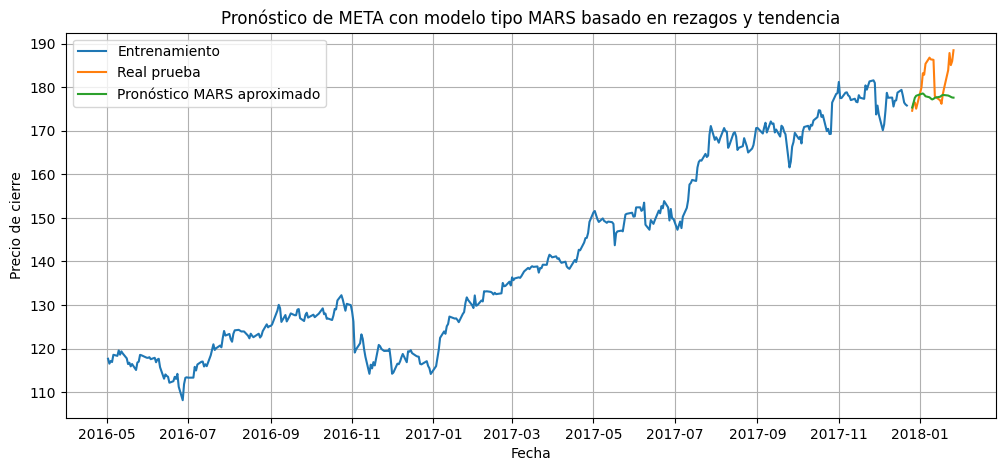

In [41]:
plt.figure(figsize=(12, 5))

plt.plot(mars_train.index, mars_train["Meta"], label="Entrenamiento")
plt.plot(mars_test.index, mars_test["Meta"], label="Real prueba")
plt.plot(resultados_mars.index, resultados_mars["Pred_MARS"], label="Pronóstico MARS aproximado")

plt.title("Pronóstico de META con modelo tipo MARS basado en rezagos y tendencia")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.grid(True)
plt.show()

#### Modelo LSTM

In [42]:
data_lstm = serie.copy()
data_lstm = data_lstm.rename(columns={"Close": "Meta"})

print("Dimensión de data_lstm:", data_lstm.shape)
print(data_lstm.head())
print(data_lstm.tail())

Dimensión de data_lstm: (439, 1)
                  Meta
Date                  
2016-05-02  117.646774
2016-05-03  116.515640
2016-05-04  117.140732
2016-05-05  116.892685
2016-05-06  118.559593
                  Meta
Date                  
2018-01-22  183.926636
2018-01-23  187.875671
2018-01-24  185.097458
2018-01-25  186.020187
2018-01-26  188.520569


#### partición entrenamiento / prueba

In [43]:
split_percent = 0.95
split = int(split_percent * len(data_lstm))

lstm_train = data_lstm.iloc[:split].copy()
lstm_test = data_lstm.iloc[split:].copy()

print("Total de datos:", len(data_lstm))
print("Datos de entrenamiento:", len(lstm_train))
print("Datos de prueba:", len(lstm_test))

print("\nRango entrenamiento:")
print(lstm_train.index.min(), "hasta", lstm_train.index.max())

print("\nRango prueba:")
print(lstm_test.index.min(), "hasta", lstm_test.index.max())

Total de datos: 439
Datos de entrenamiento: 417
Datos de prueba: 22

Rango entrenamiento:
2016-05-02 00:00:00 hasta 2017-12-22 00:00:00

Rango prueba:
2017-12-26 00:00:00 hasta 2018-01-26 00:00:00


#### visualizar partición

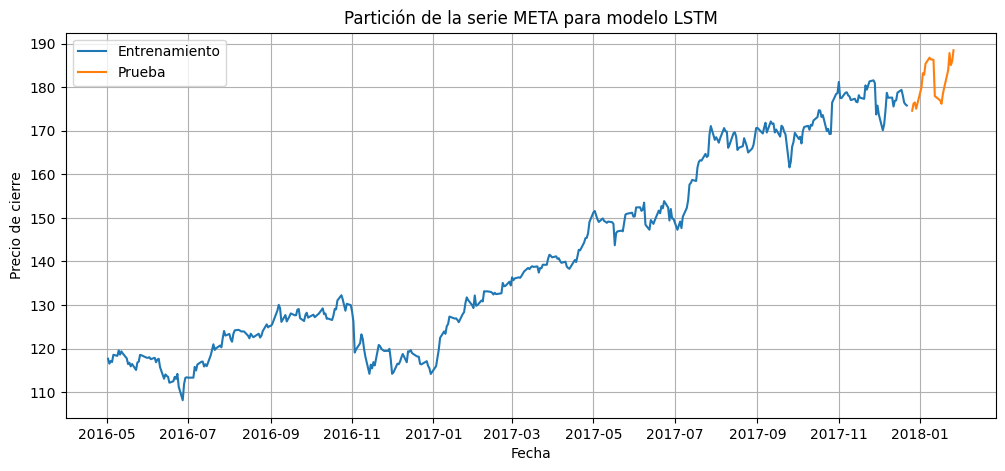

In [44]:
plt.figure(figsize=(12, 5))

plt.plot(lstm_train.index, lstm_train["Meta"], label="Entrenamiento")
plt.plot(lstm_test.index, lstm_test["Meta"], label="Prueba")

plt.title("Partición de la serie META para modelo LSTM")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.grid(True)
plt.show()

#### Escalamiento de datos para LSTM


In [45]:
from sklearn.preprocessing import MinMaxScaler

scaler_lstm = MinMaxScaler(feature_range=(0, 1))

# Ajustamos el escalador únicamente con entrenamiento
lstm_train_scaled = scaler_lstm.fit_transform(lstm_train[["Meta"]])

# Transformamos prueba con el mismo escalador
lstm_test_scaled = scaler_lstm.transform(lstm_test[["Meta"]])

print("Dimensión lstm_train_scaled:", lstm_train_scaled.shape)
print("Dimensión lstm_test_scaled:", lstm_test_scaled.shape)

print("\nPrimeros valores escalados entrenamiento:")
print(lstm_train_scaled[:5])

Dimensión lstm_train_scaled: (417, 1)
Dimensión lstm_test_scaled: (22, 1)

Primeros valores escalados entrenamiento:
[[0.12962464]
 [0.11423158]
 [0.12273815]
 [0.1193626 ]
 [0.14204676]]


#### generacion ventana LSTM

In [47]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

n_back_lstm = 10

train_generator_lstm = TimeseriesGenerator(
    lstm_train_scaled,
    lstm_train_scaled,
    length=n_back_lstm,
    batch_size=25
)

test_generator_lstm = TimeseriesGenerator(
    lstm_test_scaled,
    lstm_test_scaled,
    length=n_back_lstm,
    batch_size=1
)

print("Número de batches en train_generator_lstm:", len(train_generator_lstm))
print("Número de batches en test_generator_lstm:", len(test_generator_lstm))

x_sample, y_sample = train_generator_lstm[0]

print("Forma de X en un batch:", x_sample.shape)
print("Forma de y en un batch:", y_sample.shape)

Número de batches en train_generator_lstm: 17
Número de batches en test_generator_lstm: 12
Forma de X en un batch: (25, 10, 1)
Forma de y en un batch: (25, 1)


#### Definición de la arquitectura LSTM

In [48]:
# ==============================
# Definición de la arquitectura LSTM
# ==============================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model_lstm = Sequential()

model_lstm.add(
    LSTM(
        200,
        activation="relu",
        input_shape=(n_back_lstm, 1)
    )
)

model_lstm.add(Dense(1))

model_lstm.compile(
    optimizer="adam",
    loss="mse"
)

model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 200)            │       161,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,801 (632.04 KB)

 Trainable params: 161,801 (632.04 KB)

 Non-trainable params: 0 (0.00 B)

#### entrenamiento modelo LSTM 

In [50]:
num_epochs_lstm = 30

history_lstm = model_lstm.fit(
    train_generator_lstm,
    epochs=num_epochs_lstm,
    verbose=1
)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0017
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0017
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0020
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0012    
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014
Epoch 9/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 10/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0015
Epoch 11/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0020
Epoch 12/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0015
Epoch 13/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023
Epoch 14/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0024
Epoch 15/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0025
Epoch 16/30
17/

#### curva oerdida del entrenamiento 

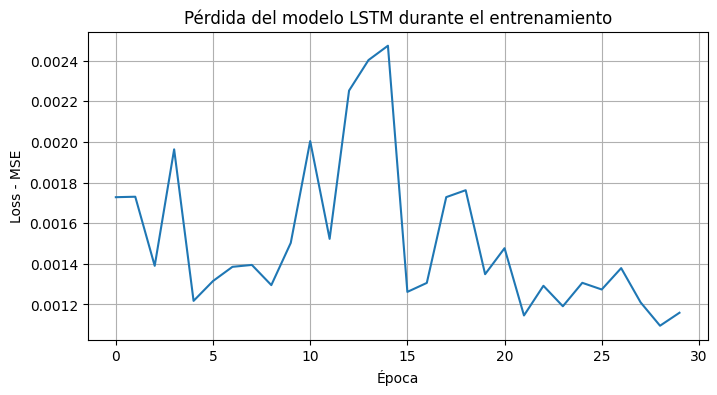

In [52]:
plt.figure(figsize=(8, 4))

plt.plot(history_lstm.history["loss"])

plt.title("Pérdida del modelo LSTM durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss - MSE")
plt.grid(True)
plt.show()

La curva de pérdida del modelo LSTM muestra oscilaciones durante el entrenamiento, pero se mantiene en valores bajos de MSE. Esto indica que la red logró ajustar la serie escalada, aunque el entrenamiento no presenta una disminución completamente monótona. Este comportamiento puede deberse al tamaño reducido del conjunto de datos y a la sensibilidad de las redes LSTM frente a la inicialización de pesos y los lotes de entrenamiento.

#### Pronóstico recursivo LSTM sobre prueba


In [53]:
historial_lstm = list(lstm_train_scaled.flatten())
pred_lstm_scaled = []

for i in range(len(lstm_test)):
    # Tomamos los últimos n_back_lstm valores escalados
    ultimos_valores = historial_lstm[-n_back_lstm:]
    
    # Forma requerida por LSTM: (muestras, pasos, variables)
    X_pred = np.array(ultimos_valores).reshape(1, n_back_lstm, 1)
    
    # Predicción escalada
    pred_scaled = model_lstm.predict(X_pred, verbose=0)[0][0]
    pred_lstm_scaled.append(pred_scaled)
    
    # Agregamos la predicción al historial para continuar de forma recursiva
    historial_lstm.append(pred_scaled)

# Convertimos las predicciones a la escala original
pred_lstm = scaler_lstm.inverse_transform(
    np.array(pred_lstm_scaled).reshape(-1, 1)
).flatten()

print("Pronóstico LSTM sobre prueba generado correctamente")
print(pred_lstm[:5])

Pronóstico LSTM sobre prueba generado correctamente
[176.04198 175.89435 175.84317 175.73947 175.59369]


#### Resultados LSTM sobre prueba

In [54]:
resultados_lstm = pd.DataFrame({
    "Real": lstm_test["Meta"].values,
    "Pred_LSTM": pred_lstm
}, index=lstm_test.index)

resultados_lstm.head()

,Real,Pred_LSTM
Date,,
2017-12-26,174.619675,176.041977
2017-12-27,176.236969,175.894348
2017-12-28,176.534653,175.843170
2017-12-29,175.086029,175.739471
2018-01-02,180.007370,175.593689


#### Métricas LSTM sobre prueba

In [56]:
mae_lstm, rmse_lstm, mape_lstm = calcular_metricas(
    resultados_lstm["Real"],
    resultados_lstm["Pred_LSTM"]
)

metricas_lstm = pd.DataFrame({
    "Modelo": ["LSTM"],
    "MAE": [mae_lstm],
    "RMSE": [rmse_lstm],
    "MAPE (%)": [mape_lstm]
})

metricas_lstm

,Modelo,MAE,RMSE,MAPE (%)
0,LSTM,7.762967,9.215977,4.203785


#### graficar el pronóstico LSTM.

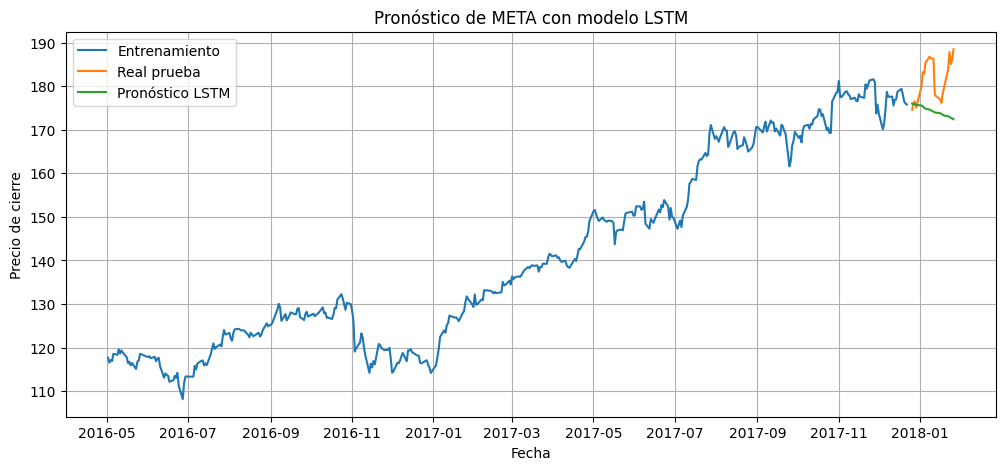

In [57]:
plt.figure(figsize=(12, 5))

plt.plot(lstm_train.index, lstm_train["Meta"], label="Entrenamiento")
plt.plot(lstm_test.index, lstm_test["Meta"], label="Real prueba")
plt.plot(resultados_lstm.index, resultados_lstm["Pred_LSTM"], label="Pronóstico LSTM")

plt.title("Pronóstico de META con modelo LSTM")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.grid(True)
plt.show()

El modelo LSTM genera un pronóstico dentro de un rango razonable al inicio del conjunto de prueba; sin embargo, tiende a proyectar una trayectoria descendente y suavizada. Esto limita su capacidad para capturar el incremento observado en la serie real durante enero de 2018. Aunque el modelo entrenó correctamente y presentó una pérdida baja en entrenamiento, su desempeño fuera de muestra fue inferior al de Random Forest y MARS aproximado.

###  SSA

In [58]:
data_ssa = serie.copy()
data_ssa = data_ssa.rename(columns={"Close": "Meta"})

print("Dimensión de data_ssa:", data_ssa.shape)
print(data_ssa.head())
print(data_ssa.tail())

Dimensión de data_ssa: (439, 1)
                  Meta
Date                  
2016-05-02  117.646774
2016-05-03  116.515640
2016-05-04  117.140732
2016-05-05  116.892685
2016-05-06  118.559593
                  Meta
Date                  
2018-01-22  183.926636
2018-01-23  187.875671
2018-01-24  185.097458
2018-01-25  186.020187
2018-01-26  188.520569


#### Partición entrenamiento 

In [59]:
split_percent = 0.95
split = int(split_percent * len(data_ssa))

ssa_train = data_ssa.iloc[:split].copy()
ssa_test = data_ssa.iloc[split:].copy()

print("Total de datos:", len(data_ssa))
print("Datos de entrenamiento:", len(ssa_train))
print("Datos de prueba:", len(ssa_test))

print("\nRango entrenamiento:")
print(ssa_train.index.min(), "hasta", ssa_train.index.max())

print("\nRango prueba:")
print(ssa_test.index.min(), "hasta", ssa_test.index.max())

Total de datos: 439
Datos de entrenamiento: 417
Datos de prueba: 22

Rango entrenamiento:
2016-05-02 00:00:00 hasta 2017-12-22 00:00:00

Rango prueba:
2017-12-26 00:00:00 hasta 2018-01-26 00:00:00


#### visualizar partición

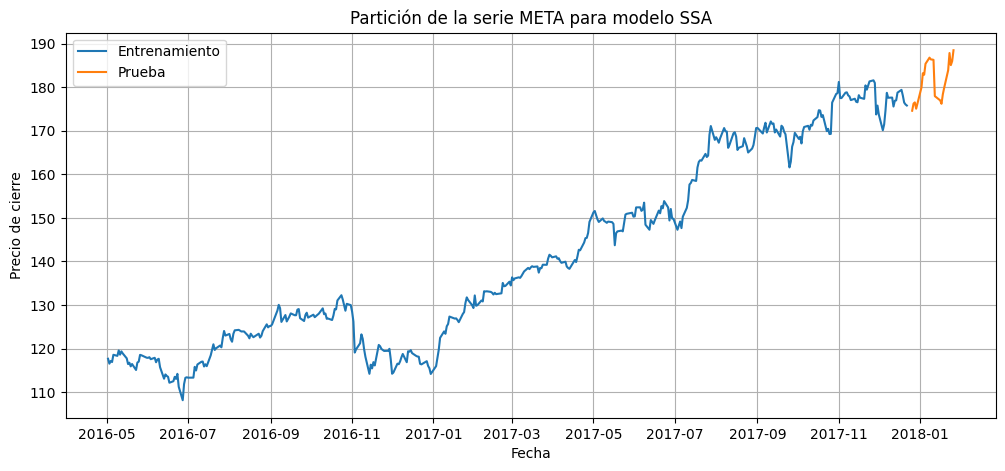

In [60]:
# ==============================
# Visualización entrenamiento / prueba para SSA
# ==============================

plt.figure(figsize=(12, 5))

plt.plot(ssa_train.index, ssa_train["Meta"], label="Entrenamiento")
plt.plot(ssa_test.index, ssa_test["Meta"], label="Prueba")

plt.title("Partición de la serie META para modelo SSA")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.grid(True)
plt.show()

####  Funciones auxiliares para SSA


In [61]:
def crear_matriz_trayectoria(serie, L):
    serie = np.array(serie)
    K = len(serie) - L + 1
    X = np.column_stack([serie[i:i+L] for i in range(K)])
    return X


def diagonal_averaging(X):
    L, K = X.shape
    N = L + K - 1
    
    serie_reconstruida = np.zeros(N)
    conteos = np.zeros(N)
    
    for i in range(L):
        for j in range(K):
            serie_reconstruida[i + j] += X[i, j]
            conteos[i + j] += 1
    
    return serie_reconstruida / conteos

#### Embedding SSA y descomposición SVD

In [62]:
serie_train_ssa = ssa_train["Meta"].values

L_ssa = 30

X_ssa = crear_matriz_trayectoria(serie_train_ssa, L_ssa)

U, s, Vt = np.linalg.svd(X_ssa, full_matrices=False)

print("Dimensión matriz trayectoria:", X_ssa.shape)
print("Cantidad de valores singulares:", len(s))
print("Primeros 10 valores singulares:")
print(s[:10])

Dimensión matriz trayectoria: (30, 388)
Cantidad de valores singulares: 30
Primeros 10 valores singulares:
[15335.19031772   240.76642263   131.03708934    93.4323897
    73.93592093    56.40400244    50.31892922    45.68814012
    42.23430547    40.11192369]


In [63]:
#### Varianza explicada por componentes SSA

In [64]:
varianza_explicada_ssa = (s**2) / np.sum(s**2)

tabla_varianza_ssa = pd.DataFrame({
    "Componente": np.arange(1, len(s) + 1),
    "Valor singular": s,
    "Varianza explicada": varianza_explicada_ssa,
    "Varianza acumulada": np.cumsum(varianza_explicada_ssa)
})

tabla_varianza_ssa.head(10)

,Componente,Valor singular,Varianza explicada,Varianza acumulada
0,1,15335.190318,0.999536,0.999536
1,2,240.766423,0.000246,0.999782
2,3,131.037089,0.000073,0.999855
3,4,93.432390,0.000037,0.999892
4,5,73.935921,0.000023,0.999915
5,6,56.404002,0.000014,0.999929
6,7,50.318929,0.000011,0.999940
7,8,45.688140,0.000009,0.999949
8,9,42.234305,0.000008,0.999956
9,10,40.111924,0.000007,0.999963


In [ ]:
# Reconstrucción SSA con componente principal


In [65]:
n_componentes_ssa = 1

X_reconstruida = np.zeros_like(X_ssa)

for i in range(n_componentes_ssa):
    Xi = s[i] * np.outer(U[:, i], Vt[i, :])
    X_reconstruida += Xi

serie_reconstruida_ssa = diagonal_averaging(X_reconstruida)

print("Longitud serie original entrenamiento:", len(serie_train_ssa))
print("Longitud serie reconstruida SSA:", len(serie_reconstruida_ssa))
print("Primeros valores reconstruidos:")
print(serie_reconstruida_ssa[:5])

Longitud serie original entrenamiento: 417
Longitud serie reconstruida SSA: 417
Primeros valores reconstruidos:
[115.38875252 115.39805893 115.4156332  115.42803875 115.43178315]


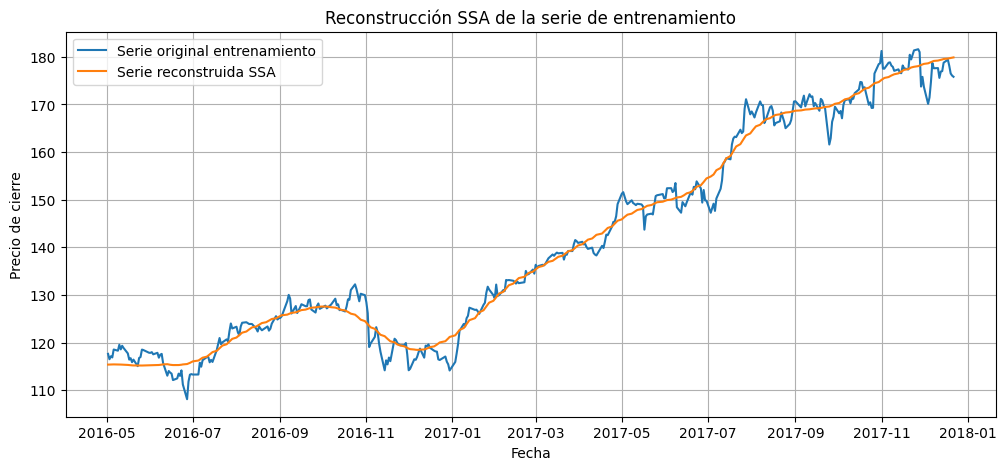

In [66]:
# ==============================
# Visualización de la reconstrucción SSA
# ==============================

plt.figure(figsize=(12, 5))

plt.plot(ssa_train.index, ssa_train["Meta"], label="Serie original entrenamiento")
plt.plot(ssa_train.index, serie_reconstruida_ssa, label="Serie reconstruida SSA")

plt.title("Reconstrucción SSA de la serie de entrenamiento")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.grid(True)
plt.show()

La reconstrucción SSA con el primer componente captura la tendencia principal del precio de cierre de META y suaviza las fluctuaciones de corto plazo. Esto es consistente con la alta proporción de varianza explicada por el primer componente, el cual concentra la estructura dominante de la serie. Sin embargo, al usar solo este componente, el modelo no reproduce completamente la volatilidad diaria, sino una versión suavizada de la trayectoria histórica.

In [67]:
# Pronóstico SSA sobre conjunto de prueba


from sklearn.linear_model import LinearRegression

# Variable temporal sobre la serie reconstruida
X_train_ssa_forecast = np.arange(len(serie_reconstruida_ssa)).reshape(-1, 1)
y_train_ssa_forecast = serie_reconstruida_ssa

# Modelo lineal sobre la señal reconstruida
modelo_ssa_forecast = LinearRegression()
modelo_ssa_forecast.fit(X_train_ssa_forecast, y_train_ssa_forecast)

# Horizonte de prueba
X_test_ssa_forecast = np.arange(
    len(serie_reconstruida_ssa),
    len(serie_reconstruida_ssa) + len(ssa_test)
).reshape(-1, 1)

pred_ssa = modelo_ssa_forecast.predict(X_test_ssa_forecast)

print("Pronóstico SSA sobre prueba generado correctamente")
print(pred_ssa[:5])

Pronóstico SSA sobre prueba generado correctamente
[177.03663171 177.20860503 177.38057834 177.55255166 177.72452498]


In [68]:
# Resultados SSA sobre prueba
# 

resultados_ssa = pd.DataFrame({
    "Real": ssa_test["Meta"].values,
    "Pred_SSA": pred_ssa
}, index=ssa_test.index)

resultados_ssa.head()

,Real,Pred_SSA
Date,,
2017-12-26,174.619675,177.036632
2017-12-27,176.236969,177.208605
2017-12-28,176.534653,177.380578
2017-12-29,175.086029,177.552552
2018-01-02,180.007370,177.724525


In [69]:
# ==============================
# Métricas SSA sobre prueba
# ==============================

mae_ssa, rmse_ssa, mape_ssa = calcular_metricas(
    resultados_ssa["Real"],
    resultados_ssa["Pred_SSA"]
)

metricas_ssa = pd.DataFrame({
    "Modelo": ["SSA"],
    "MAE": [mae_ssa],
    "RMSE": [rmse_ssa],
    "MAPE (%)": [mape_ssa]
})

metricas_ssa

,Modelo,MAE,RMSE,MAPE (%)
0,SSA,4.335323,5.115854,2.352233


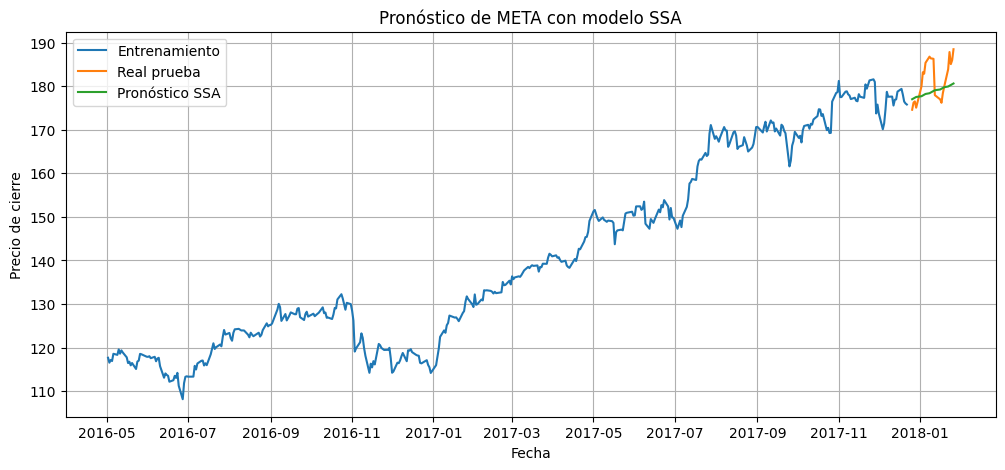

In [70]:
# Gráfico del pronóstico SSA

plt.figure(figsize=(12, 5))

plt.plot(ssa_train.index, ssa_train["Meta"], label="Entrenamiento")
plt.plot(ssa_test.index, ssa_test["Meta"], label="Real prueba")
plt.plot(resultados_ssa.index, resultados_ssa["Pred_SSA"], label="Pronóstico SSA")

plt.title("Pronóstico de META con modelo SSA")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.grid(True)
plt.show()

In [71]:
# Comparación final de modelos

metricas_modelos = pd.concat([
    metricas_rf_final,
    metricas_mars,
    metricas_lstm,
    metricas_ssa
], ignore_index=True)

metricas_modelos = metricas_modelos.sort_values("RMSE").reset_index(drop=True)

metricas_modelos

,Modelo,MAE,RMSE,MAPE (%)
0,SSA,4.335323,5.115854,2.352233
1,MARS aproximado con splines,4.840191,6.102007,2.614761
2,Random Forest refinado,4.970664,6.117778,2.684428
3,LSTM,7.762967,9.215977,4.203785


A partir de las métricas de evaluación, el modelo SSA presentó el mejor desempeño sobre el conjunto de prueba, con un MAE de 4.3353, un RMSE de 5.1159 y un MAPE de 2.3522%. Esto indica que fue el modelo con menor error promedio, menor penalización frente a errores grandes y menor error porcentual relativo.

El segundo mejor modelo fue el MARS aproximado con splines, con un desempeño cercano al SSA. Random Forest refinado presentó un resultado aceptable, aunque inferior a los dos anteriores. Por su parte, LSTM obtuvo los mayores errores, posiblemente porque el tamaño de la serie no fue suficiente para que la red neuronal generalizara adecuadamente y porque su pronóstico tendió a suavizar o subestimar la tendencia alcista del conjunto de prueba.

Con base en estos resultados, el modelo seleccionado para generar el pronóstico final es SSA, ya que fue el que presentó el mejor desempeño de acuerdo con las tres métricas evaluadas.

In [72]:
# SSA sobre toda la serie para pronóstico futuro

serie_full_ssa = data_ssa["Meta"].values

L_ssa = 30

X_full_ssa = crear_matriz_trayectoria(serie_full_ssa, L_ssa)

U_full, s_full, Vt_full = np.linalg.svd(X_full_ssa, full_matrices=False)

# Reconstrucción con el primer componente
n_componentes_ssa = 1

X_full_reconstruida = np.zeros_like(X_full_ssa)

for i in range(n_componentes_ssa):
    Xi = s_full[i] * np.outer(U_full[:, i], Vt_full[i, :])
    X_full_reconstruida += Xi

serie_full_reconstruida_ssa = diagonal_averaging(X_full_reconstruida)

print("Longitud serie original:", len(serie_full_ssa))
print("Longitud serie reconstruida:", len(serie_full_reconstruida_ssa))

Longitud serie original: 439
Longitud serie reconstruida: 439


In [73]:
# Pronóstico futuro con SSA

from sklearn.linear_model import LinearRegression

# Modelo de tendencia sobre la serie reconstruida
X_full_forecast = np.arange(len(serie_full_reconstruida_ssa)).reshape(-1, 1)
y_full_forecast = serie_full_reconstruida_ssa

modelo_ssa_futuro = LinearRegression()
modelo_ssa_futuro.fit(X_full_forecast, y_full_forecast)

# Pronóstico 10 días adelante
steps_futuro = 10

X_futuro_ssa = np.arange(
    len(serie_full_reconstruida_ssa),
    len(serie_full_reconstruida_ssa) + steps_futuro
).reshape(-1, 1)

pred_ssa_futuro = modelo_ssa_futuro.predict(X_futuro_ssa)

# Fechas futuras en días hábiles
fecha_inicio_futuro = data_ssa.index.max() + pd.tseries.offsets.BDay(1)

fechas_futuras_ssa = pd.bdate_range(
    start=fecha_inicio_futuro,
    periods=steps_futuro
)

pronostico_ssa_futuro = pd.DataFrame({
    "Fecha": fechas_futuras_ssa,
    "Pronostico_SSA": pred_ssa_futuro
})

pronostico_ssa_futuro

,Fecha,Pronostico_SSA
0,2018-01-29,181.020675
1,2018-01-30,181.193338
2,2018-01-31,181.366001
3,2018-02-01,181.538664
4,2018-02-02,181.711327
5,2018-02-05,181.883990
6,2018-02-06,182.056653
7,2018-02-07,182.229315
8,2018-02-08,182.401978
9,2018-02-09,182.574641


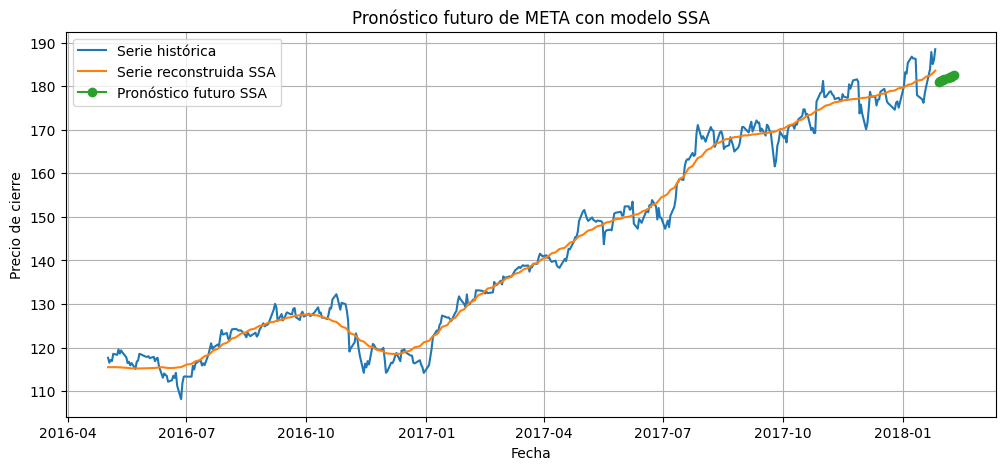

In [74]:
# Gráfico pronóstico futuro SSA

plt.figure(figsize=(12, 5))

plt.plot(data_ssa.index, data_ssa["Meta"], label="Serie histórica")
plt.plot(data_ssa.index, serie_full_reconstruida_ssa, label="Serie reconstruida SSA")
plt.plot(fechas_futuras_ssa, pred_ssa_futuro, label="Pronóstico futuro SSA", marker="o")

plt.title("Pronóstico futuro de META con modelo SSA")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.grid(True)
plt.show()